# 🌿 Pest Risk Detection — AIoT Smart Farming
## LD7182 AI for IoT | Sustainable Farming

**Dataset:** [Smart Farming Data 2024 (SF24) — Kaggle](https://www.kaggle.com/datasets/datasetengineer/smart-farming-data-2024-sf24)  
**Model:** Decision Tree Classifier  
**Target:** Pest Pressure Risk → `Low` / `Medium` / `High`  
**Deployment:** EloquentML on ESP32 (Arduino C++)  
**Cloud:** Adafruit IO Dashboard

In [1]:
# ── Cell 1: Install Dependencies ──
!pip install micromlgen pandas scikit-learn matplotlib seaborn

In [2]:
# ── Cell 2: Imports ──
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
import json
print(' Imports OK')

 Imports OK


In [3]:
# ── Cell 3: Upload Dataset ──
from google.colab import files
print('Upload smart_farming_2024.csv from Kaggle...')
uploaded = files.upload()

Upload smart_farming_2024.csv from Kaggle...


Saving Crop_recommendationV2.csv to Crop_recommendationV2 (2).csv


In [34]:
# ── Cell 4: Load & Explore ──
import os
for fname in os.listdir('.'):
    if fname.endswith('.csv'):
        print('Found:', fname)

df = pd.read_csv('Crop_recommendationV2.csv')
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
display(df.head())
display(df.tail())
print('\nData types:')
print(df.dtypes)

Found: Crop_recommendationV2 (2).csv
Found: Crop_recommendationV2.csv
Found: Crop_recommendationV2 (1).csv
Shape: (2200, 23)

Columns:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'soil_moisture', 'soil_type', 'sunlight_exposure', 'wind_speed', 'co2_concentration', 'organic_matter', 'irrigation_frequency', 'crop_density', 'pest_pressure', 'fertilizer_usage', 'growth_stage', 'urban_area_proximity', 'water_source_type', 'frost_risk', 'water_usage_efficiency']


,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,29.446064,2,...,3.121395,4,11.743910,57.607308,188.194958,1,2.719614,3,95.649985,1.193293
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,12.851183,3,...,2.142021,4,16.797101,74.736879,70.963629,1,4.714427,2,77.265694,1.752672
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,29.363913,2,...,1.474974,1,12.654395,1.034478,191.976077,1,30.431736,2,18.192168,3.035541
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,26.207732,3,...,8.393907,1,10.864360,24.091888,55.761388,3,10.861071,3,82.818720,1.273341
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,28.236236,2,...,5.202285,3,13.852910,38.811481,185.259702,2,47.190777,3,25.466499,2.578671


,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee,10.697757,1,...,4.720355,5,18.597260,87.431199,185.833381,3,31.415618,1,77.719639,4.111619
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee,12.203830,3,...,4.141148,6,15.417979,36.958354,198.541021,2,18.797510,3,22.336839,4.190796
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee,28.989176,3,...,1.599614,5,12.956675,79.678658,86.724381,2,38.805888,3,41.782729,2.447010
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee,13.642305,2,...,8.934077,6,16.868131,31.007156,72.191421,2,8.395498,3,49.619791,4.119388
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee,23.911728,3,...,6.401994,3,14.652123,3.574191,175.104241,3,26.784996,2,47.271267,2.758819



Data types:
N                           int64
P                           int64
K                           int64
temperature               float64
humidity                  float64
ph                        float64
rainfall                  float64
label                      object
soil_moisture             float64
soil_type                   int64
sunlight_exposure         float64
wind_speed                float64
co2_concentration         float64
organic_matter            float64
irrigation_frequency        int64
crop_density              float64
pest_pressure             float64
fertilizer_usage          float64
growth_stage                int64
urban_area_proximity      float64
water_source_type           int64
frost_risk                float64
water_usage_efficiency    float64
dtype: object


Pest Pressure stats:
count    2200.000000
mean       49.850701
std        28.886354
min         0.038103
25%        24.379866
50%        49.982421
75%        74.681904
max        99.983849
Name: pest_pressure, dtype: float64


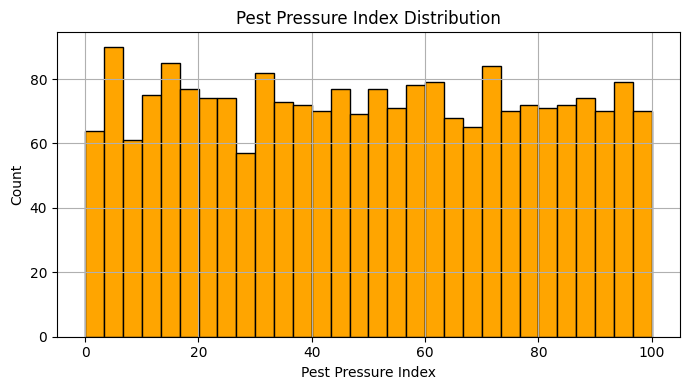

In [5]:
# ── Cell 5: Explore Pest Pressure Column ──
print('Pest Pressure stats:')
print(df['pest_pressure'].describe())

plt.figure(figsize=(7,4))
df['pest_pressure'].hist(bins=30, color='orange', edgecolor='black')
plt.title('Pest Pressure Index Distribution')
plt.xlabel('Pest Pressure Index')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('pest_pressure_distribution.png', dpi=150)
plt.show()

In [6]:
pest_min = df['pest_pressure'].min()
pest_max = df['pest_pressure'].max()
pest_mid1 = pest_min + (pest_max - pest_min) / 3
pest_mid2 = pest_min + 2 * (pest_max - pest_min) / 3

df['pest_risk'] = pd.cut(
    df['pest_pressure'],
    bins=[pest_min - 0.01, pest_mid1, pest_mid2, pest_max],
    labels=['Low', 'Medium', 'High']
)

print('Risk class distribution:')
print(df['pest_risk'].value_counts())

Risk class distribution:
pest_risk
Low       739
Medium    734
High      727
Name: count, dtype: int64


In [18]:
# ── Cell 7: Feature Selection ──
df['thi'] = df['temperature'] * df['humidity'] / 100

FEATURES = [
    'temperature',
    'humidity',
    'sunlight_exposure',
    'wind_speed',
    'co2_concentration',
    'thi'
]
TARGET = 'pest_risk'   # ← binned column, not pest_pressure

for f in FEATURES:
    if f not in df.columns:
        print(f'  Missing: {f}')
    else:
        print(f'  Found: {f}')

X = df[FEATURES]
y = df[TARGET]   # ← Low/Medium/High labels

print(f'\nX shape: {X.shape}')
print('Missing values:', X.isnull().sum().sum())

  Found: temperature
  Found: humidity
  Found: sunlight_exposure
  Found: wind_speed
  Found: co2_concentration
  Found: thi

X shape: (2200, 6)
Missing values: 0


In [19]:
# Cell 8 - encode the BINNED label, not pest_pressure float
le = LabelEncoder()
y_encoded = le.fit_transform(df['pest_risk'])  # ← pest_risk not pest_pressure
class_names = le.classes_

print('Class encoding:')
for i, name in enumerate(class_names):
    print(f'  {i} → {name}')

Class encoding:
  0 → High
  1 → Low
  2 → Medium


In [20]:
print(df['pest_risk'].value_counts())
print(df['pest_risk'].isna().sum())

pest_risk
Low       739
Medium    734
High      727
Name: count, dtype: int64
0


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=7
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 1760 | Test: 440


In [22]:
# ── Cell 10: Train Decision Tree ──
# max_depth=8 → lightweight for ESP32 edge deployment
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    criterion='gini',
    random_state=7
)
dt.fit(X_train, y_train)
print(' Decision Tree trained!')
print(f'Tree depth: {dt.get_depth()}')
print(f'Leaf nodes: {dt.get_n_leaves()}')

 Decision Tree trained!
Tree depth: 8
Leaf nodes: 92


In [23]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=7)
cv_scores = cross_val_score(dt, X, y_encoded, cv=kf, scoring='accuracy')
print(f'5-Fold CV Accuracy: {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%')
print(f'Scores: {[round(s*100,2) for s in cv_scores]}')

5-Fold CV Accuracy: 33.64% ± 1.81%
Scores: [np.float64(36.36), np.float64(31.14), np.float64(34.77), np.float64(32.5), np.float64(33.41)]


In [24]:
# ── Cell 12: Evaluate on Test Set ──
y_pred = dt.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f' Test Accuracy: {acc * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=class_names))

 Test Accuracy: 36.36%

Classification Report:
              precision    recall  f1-score   support

        High       0.41      0.28      0.34       151
         Low       0.40      0.24      0.30       153
      Medium       0.33      0.59      0.42       136

    accuracy                           0.36       440
   macro avg       0.38      0.37      0.35       440
weighted avg       0.38      0.36      0.35       440



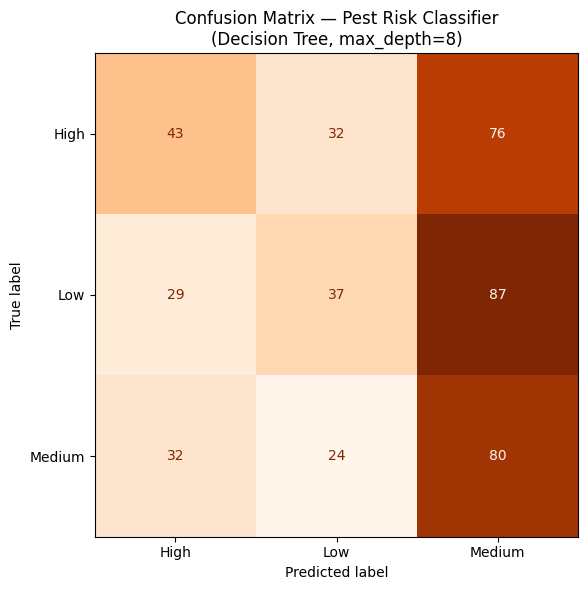

Saved: confusion_matrix.png


In [25]:
# ── Cell 13: Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('Confusion Matrix — Pest Risk Classifier\n(Decision Tree, max_depth=8)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

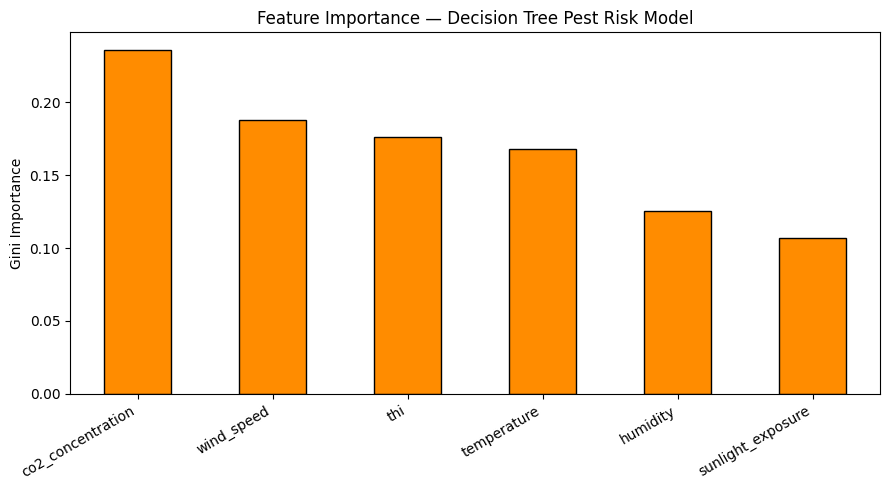

Saved: feature_importance.png


In [26]:
# ── Cell 14: Feature Importance ──
feat_imp = pd.Series(dt.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Feature Importance — Decision Tree Pest Risk Model')
plt.ylabel('Gini Importance')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Saved: feature_importance.png')

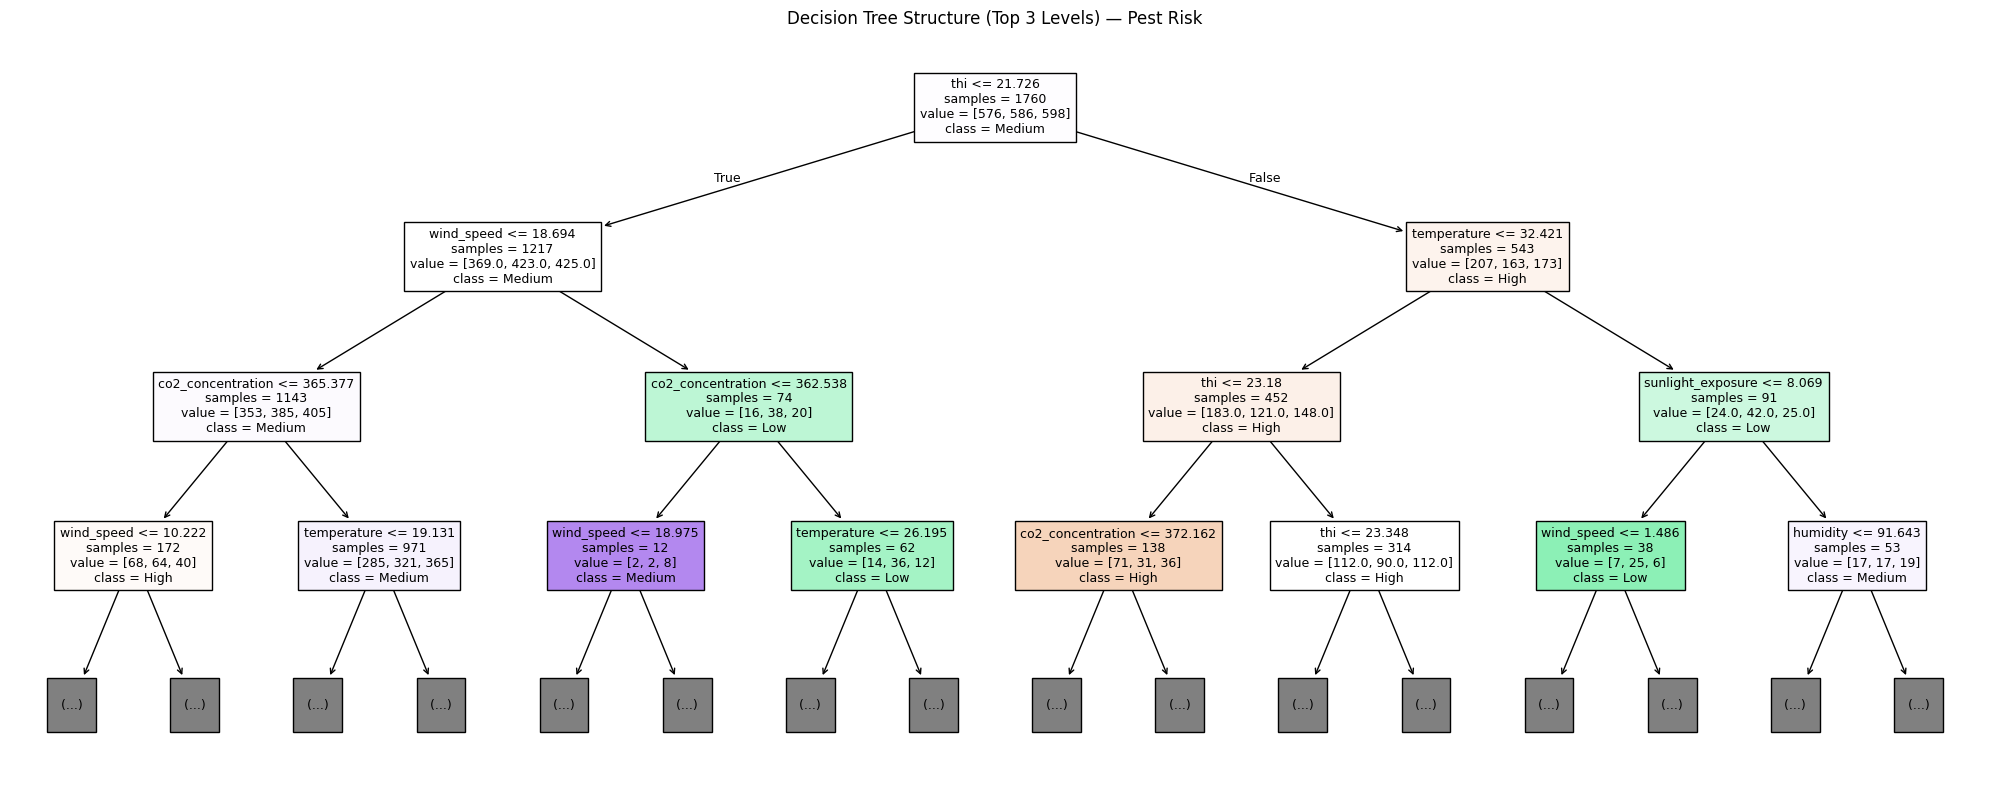

Saved: decision_tree_viz.png


In [27]:
# ── Cell 15: Visualise Decision Tree ──
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=FEATURES,
    class_names=class_names,
    filled=True,
    max_depth=3,      # show top 3 levels only
    fontsize=9,
    impurity=False
)
plt.title('Decision Tree Structure (Top 3 Levels) — Pest Risk')
plt.tight_layout()
plt.savefig('decision_tree_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: decision_tree_viz.png')

In [31]:
# ── Cell 16: Export EloquentML C++ Header ──
from micromlgen import port

cpp_code = port(dt, classname='PestRiskClassifier')

with open('pest_model.h', 'w') as f:
    f.write(cpp_code)

print(' Exported: pest_model.h')
print('Lines:', len(cpp_code.splitlines()))
print('\nCopy pest_model.h into your Wokwi/Arduino sketch folder!')

 Exported: pest_model.h
Lines: 565

Copy pest_model.h into your Wokwi/Arduino sketch folder!


In [32]:
# ── Cell 17: Save Stats & Download All Files ──
from google.colab import files

stats = {
    'model': 'DecisionTree',
    'accuracy_percent': float(round(acc * 100, 2)),
    'cv_mean_percent': float(round(cv_scores.mean() * 100, 2)),
    'cv_std_percent': float(round(cv_scores.std() * 100, 2)),
    'max_depth': int(dt.get_depth()),
    'tree_actual_depth': int(dt.get_depth()),
    'n_leaves': int(dt.get_n_leaves()),
    'features': FEATURES,
    'classes': list(class_names),
    'train_samples': int(len(X_train)),
    'test_samples': int(len(X_test)),
    'dataset': 'Smart Farming Data 2024 (SF24)'
}
with open('model_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)

print('Downloading files...')
files.download('pest_model.h')
files.download('confusion_matrix.png')
files.download('feature_importance.png')
files.download('decision_tree_viz.png')
files.download('risk_class_distribution.png')
files.download('pest_pressure_distribution.png')
files.download('model_stats.json')

print('\n=== DONE ===')
print('Key file: pest_model.h → paste into Wokwi as new file')
print(f'Accuracy: {acc*100:.2f}%')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== DONE ===
Key file: pest_model.h → paste into Wokwi as new file
Accuracy: 36.36%
